# Pink Slip Management System - Data Analysis

This notebook analyzes pink slip data to uncover trends

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

sns.set_style('whitegrid')

engine = create_engine(os.environ.get('DATABASE_URL'))

tickets_df = pd.read_sql_query('SELECT * FROM pink_slip', engine, parse_dates=['date_received', 'due_date'])
items_df = pd.read_sql_query('SELECT * FROM pink_slip_item', engine)

print(f'Total tickets: {len(tickets_df)}')
print(f'Total items: {len(items_df)}')
print(f'Date range: {tickets_df["date_received"].min()} - {tickets_df["date_received"].max()}')
print(f'\nTickets preview')
tickets_df.head()

Total tickets: 52091
Total items: 95819
Date range: 2022-01-01 00:00:00 - 2024-12-31 00:00:00

Tickets preview


,id,slip_number,first_initial,last_name,phone,date_received,due_date,due_time,total_amount,rush_fee
0,138,100138,U,Ray,(910) 765-5956,2022-01-05,2022-01-19,3:30 PM,47.0,0.0
1,317,100317,W,Liu,(910) 623-8235,2022-01-10,2022-01-24,1:30 PM,19.0,0.0
2,1911,101911,R,Kim,(980) 400-7494,2022-02-21,2022-03-07,4:30 PM,8.0,0.0
3,2024,102024,C,Kim,(980) 797-9893,2022-02-24,2022-03-10,3:00 PM,29.0,0.0
4,2886,102886,W,Cox,(980) 818-1379,2022-03-16,2022-03-30,2:00 PM,9.0,0.0


In [2]:
# check the data
print(tickets_df.dtypes)
print()
print(tickets_df.describe())
print()
print(f'Missing values:\n{tickets_df.isnull().sum()}')

id                        int64
slip_number              object
first_initial            object
last_name                object
phone                    object
date_received    datetime64[ns]
due_date         datetime64[ns]
due_time                 object
total_amount            float64
rush_fee                float64
dtype: object

                 id                  date_received  \
count  52091.000000                          52091   
mean   26046.000000  2023-07-12 15:12:00.055287808   
min        1.000000            2022-01-01 00:00:00   
25%    13023.500000            2022-10-13 00:00:00   
50%    26046.000000            2023-07-01 00:00:00   
75%    39068.500000            2024-04-22 00:00:00   
max    52091.000000            2024-12-31 00:00:00   
std    15037.520773                            NaN   

                            due_date  total_amount      rush_fee  
count                          52091  52091.000000  52091.000000  
mean   2023-07-25 07:41:30.925495552     39.

In [3]:
items_df.head(10)

,id,slip_id,item_type,work_description,price,item_number
0,1,1,Coat,Repair,20.0,1
1,2,1,Jacket,Shorten sleeves,22.0,2
2,3,2,Pants,Let out seams,12.0,1
3,4,2,Pants,Let out seams,19.0,2
4,5,3,Jacket,Take in waist,23.0,1
5,6,4,Shirt,Resize,26.0,1
6,7,5,Dress,Resize,34.0,1
7,8,6,Jeans,Repair,10.0,1
8,9,6,Jacket,Repair,17.0,2
9,10,7,Jacket,Let out seams,16.0,1


## 1. Revenue Analysis

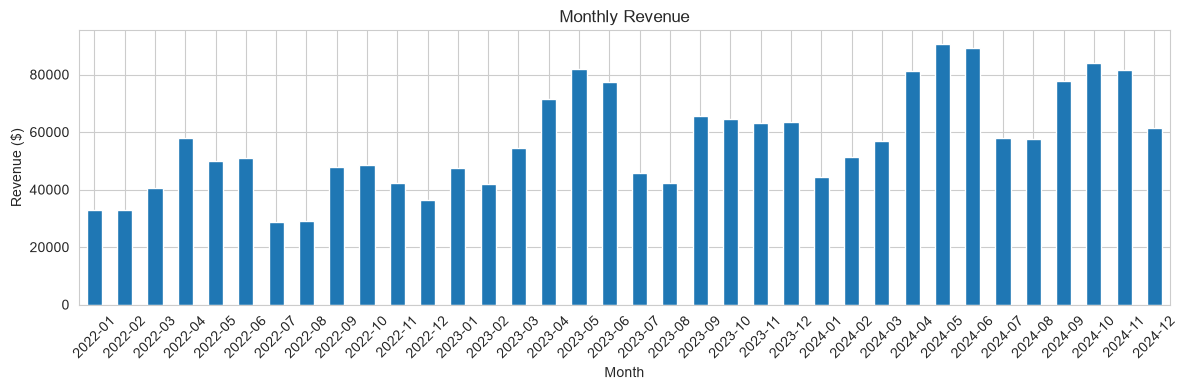

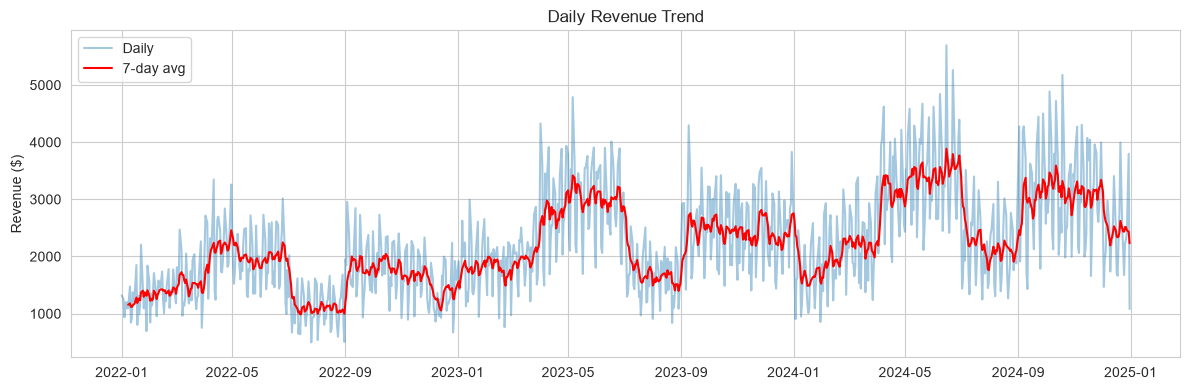

Total revenue: $2,050,464.00
Avg daily revenue: $2,183.67
Avg slip value: $39.36


In [4]:
tickets_df['month'] = tickets_df['date_received'].dt.to_period('M')
monthly_revenue = tickets_df.groupby('month')['total_amount'].sum()

# monthly revenue bar chart
plt.figure(figsize=(12, 4))
monthly_revenue.plot(kind='bar')
plt.title('Monthly Revenue')
plt.ylabel('Revenue ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# daily trend with rolling average
daily_revenue = tickets_df.groupby('date_received')['total_amount'].sum()

plt.figure(figsize=(12, 4))
plt.plot(daily_revenue.index, daily_revenue.values, alpha=0.4, label='Daily')
plt.plot(daily_revenue.index, daily_revenue.rolling(7).mean(), color='red', label='7-day avg')
plt.title('Daily Revenue Trend')
plt.ylabel('Revenue ($)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Total revenue: ${monthly_revenue.sum():,.2f}')
print(f'Avg daily revenue: ${daily_revenue.mean():,.2f}')
print(f'Avg slip value: ${tickets_df["total_amount"].mean():,.2f}')

## 2. Item Type: Volume vs. Revenue

Pants: 17,263 (18.0%)
Dress: 15,426 (16.1%)
Jacket: 14,318 (14.9%)
Shirt: 13,581 (14.2%)
Jeans: 11,273 (11.8%)
Coat: 9,368 (9.8%)
Skirt: 7,723 (8.1%)
Shorts: 3,905 (4.1%)
Other: 2,962 (3.1%)


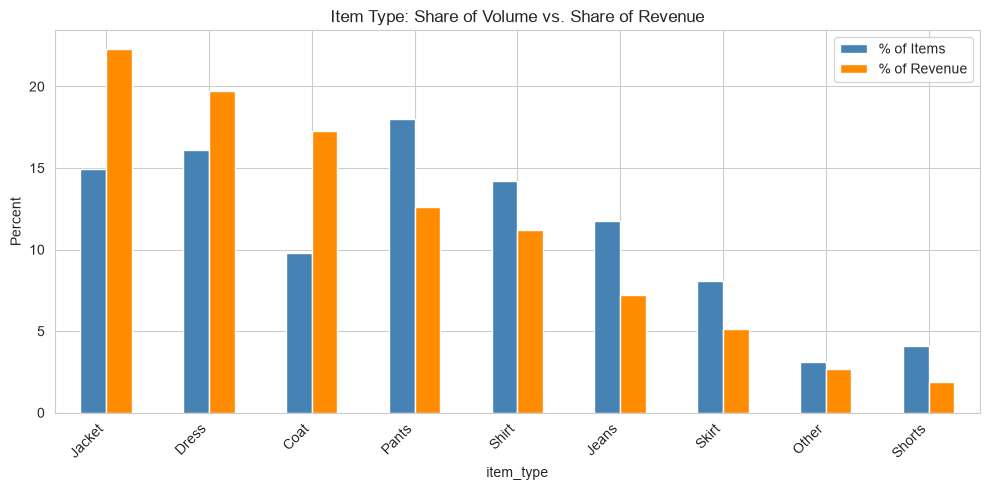

,% of Items,% of Revenue
item_type,,
Jacket,14.9,22.3
Dress,16.1,19.7
Coat,9.8,17.2
Pants,18.0,12.6
Shirt,14.2,11.2
Jeans,11.8,7.2
Skirt,8.1,5.1
Other,3.1,2.7
Shorts,4.1,1.9


In [5]:
# breakdown
item_counts = items_df['item_type'].value_counts()
for item, count in item_counts.items():
    print(f'{item}: {count:,} ({count/len(items_df)*100:.1f}%)')

volume_pct = items_df['item_type'].value_counts(normalize=True) * 100
revenue_pct = items_df.groupby('item_type')['price'].sum() / items_df['price'].sum() * 100

comparison = pd.DataFrame({
    '% of Items': volume_pct,
    '% of Revenue': revenue_pct
}).sort_values('% of Revenue', ascending=False)

comparison.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'darkorange'])
plt.ylabel('Percent')
plt.title('Item Type: Share of Volume vs. Share of Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

comparison.round(1)

## 3. Repeat Customer Behavior

Visit frequency per customer - how many times does the average customer come back?

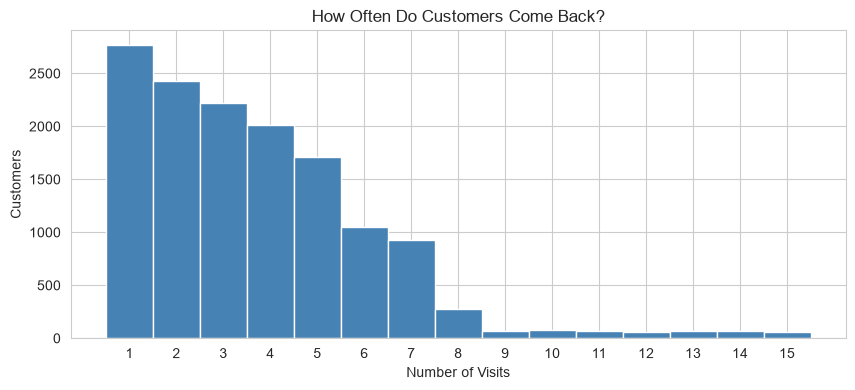

Unique customers: 13,900
Repeat customers (2+ visits): 11,131 (80.1%)
Avg visits per customer: 3.7


In [6]:
# count visits per customer using phone number
customer_visits = tickets_df.groupby('phone').agg(
    visits=('id', 'count'),
    total_spent=('total_amount', 'sum')
).reset_index()

plt.figure(figsize=(10, 4))
max_visits = min(customer_visits['visits'].max(), 15)
plt.hist(customer_visits['visits'], bins=range(1, max_visits + 2),
         color='steelblue', edgecolor='white', align='left')
plt.xlabel('Number of Visits')
plt.ylabel('Customers')
plt.title('How Often Do Customers Come Back?')
plt.xticks(range(1, max_visits + 1))
plt.show()

repeat = len(customer_visits[customer_visits['visits'] > 1])
total = len(customer_visits)
print(f'Unique customers: {total:,}')
print(f'Repeat customers (2+ visits): {repeat:,} ({repeat/total*100:.1f}%)')
print(f'Avg visits per customer: {customer_visits["visits"].mean():.1f}')

## 4. Customer Segmentation

Splitting customers into tiers by how often they visit to see which group brings in the most revenue.

               customers    revenue  pct_customers  pct_revenue
tier                                                           
One-time            2769    81959.0           19.9          4.0
Repeat (2-4)        6662   654490.0           47.9         31.9
Regular (5-9)       4037  1012983.0           29.0         49.4
VIP (10+)            432   301032.0            3.1         14.7



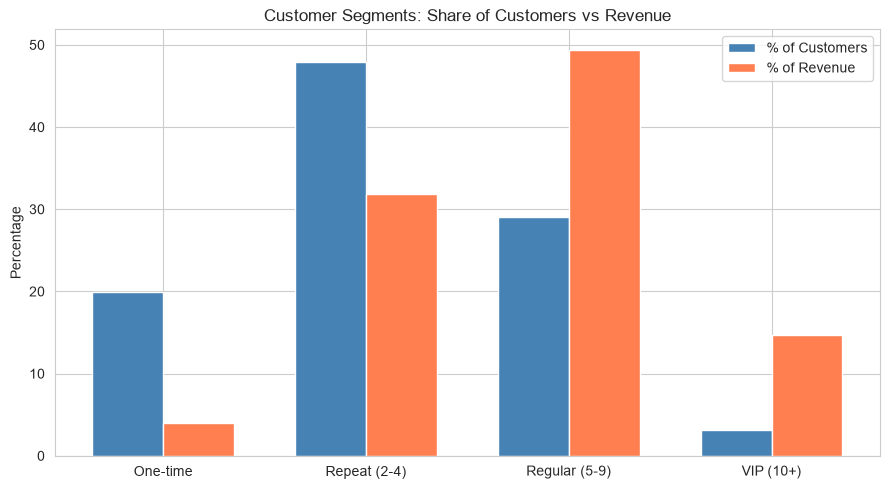

In [7]:
# tier customers by visit count
def get_tier(v):
    if v == 1: return 'One-time'
    if v <= 4: return 'Repeat (2-4)'
    if v <= 9: return 'Regular (5-9)'
    return 'VIP (10+)'

customer_visits['tier'] = customer_visits['visits'].apply(get_tier)

tier_order = ['One-time', 'Repeat (2-4)', 'Regular (5-9)', 'VIP (10+)']
tier_stats = customer_visits.groupby('tier').agg(
    customers=('phone', 'count'),
    revenue=('total_spent', 'sum')
).reindex(tier_order)

tier_stats['pct_customers'] = (tier_stats['customers'] / tier_stats['customers'].sum() * 100).round(1)
tier_stats['pct_revenue'] = (tier_stats['revenue'] / tier_stats['revenue'].sum() * 100).round(1)

print(tier_stats)
print()

# compare what % of customers each tier is vs what % of revenue they bring
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(tier_order))
w = 0.35
ax.bar([i - w/2 for i in x], tier_stats['pct_customers'], w, label='% of Customers', color='steelblue')
ax.bar([i + w/2 for i in x], tier_stats['pct_revenue'], w, label='% of Revenue', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(tier_order)
ax.set_ylabel('Percentage')
ax.set_title('Customer Segments: Share of Customers vs Revenue')
ax.legend()
plt.tight_layout()
plt.show()



## 5. Seasonal Demand

Looking at order volume by month across all years to see if there's a seasonal pattern.

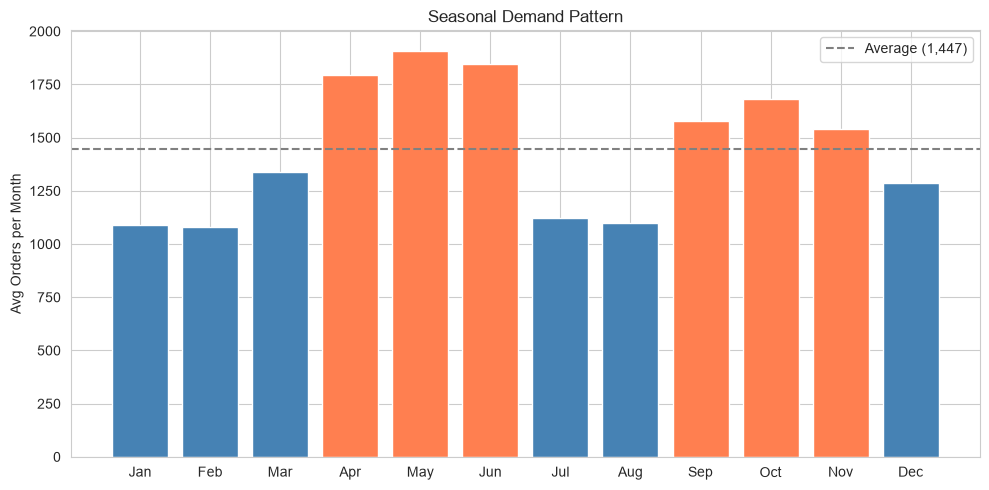

Average monthly orders: 1,447
Spring peak (Apr-Jun): 1,851 (28% above average)
Fall peak (Sep-Nov): 1,599 (11% above average)


In [8]:
# average orders per month across all years
tickets_df['month_num'] = tickets_df['date_received'].dt.month
monthly_orders = tickets_df.groupby('month_num').size() / tickets_df['date_received'].dt.year.nunique()

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
avg_monthly = monthly_orders.mean()

# color april-june and sept-nov differently to highlight peak
colors = ['coral' if val > avg_monthly else 'steelblue' for val in monthly_orders.values]

plt.figure(figsize=(10, 5))
plt.bar(month_labels, monthly_orders.values, color=colors)
plt.axhline(y=avg_monthly, color='gray', linestyle='--', label=f'Average ({avg_monthly:,.0f})')
plt.ylabel('Avg Orders per Month')
plt.title('Seasonal Demand Pattern')
plt.legend()
plt.tight_layout()
plt.show()

# peak months
spring_peak = monthly_orders.loc[4:6].mean()
fall_peak = monthly_orders.loc[9:11].mean()
spring_pct = (spring_peak - avg_monthly) / avg_monthly * 100
fall_pct = (fall_peak - avg_monthly) / avg_monthly * 100
print(f'Average monthly orders: {avg_monthly:,.0f}')
print(f'Spring peak (Apr-Jun): {spring_peak:,.0f} ({spring_pct:.0f}% above average)')
print(f'Fall peak (Sep-Nov): {fall_peak:,.0f} ({fall_pct:.0f}% above average)')


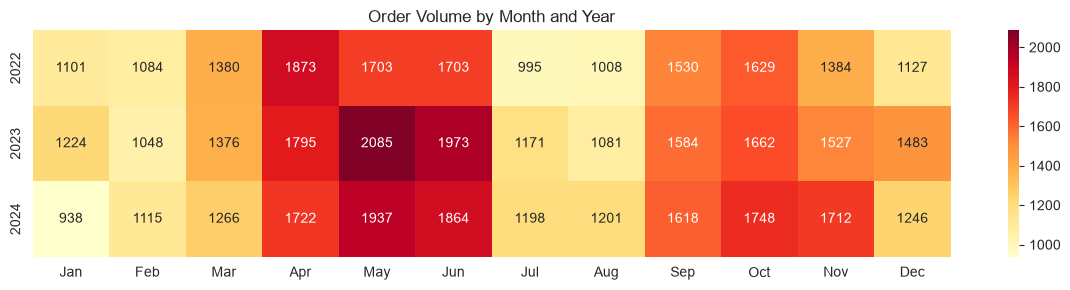

In [9]:
# heatmap of orders by month and year
tickets_df['year'] = tickets_df['date_received'].dt.year
heatmap_data = tickets_df.groupby(['year', 'month_num']).size().unstack(level=1)
heatmap_data.columns = month_labels

plt.figure(figsize=(12, 3))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Order Volume by Month and Year')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 6. Cohort Retention

Grouping customers by the month of their first visit, then tracking what percentage return in subsequent months.

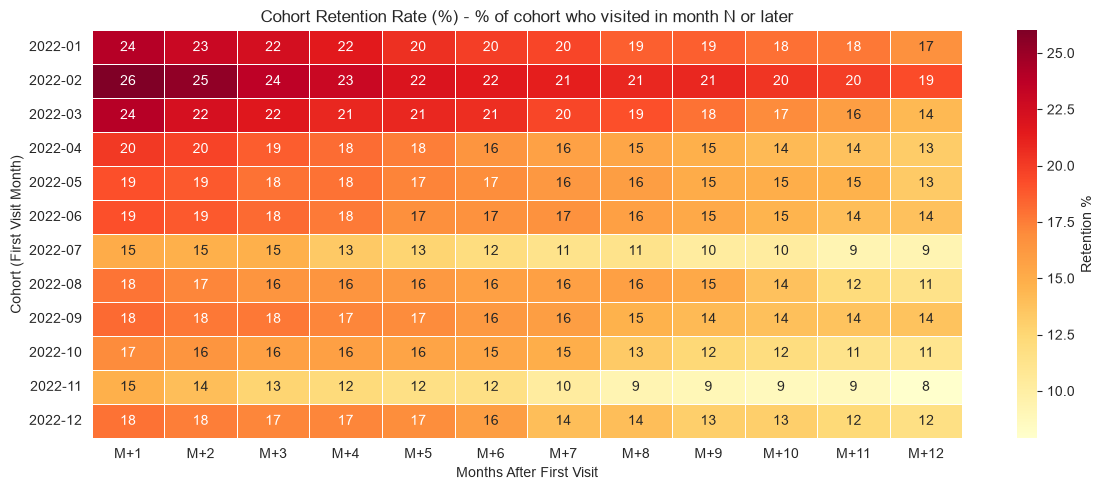

Avg month-1 retention: 19.4%
Avg month-6 retention: 16.6%
Avg month-12 retention: 13.0% (based on 12 cohorts)
Best retaining cohort (month 1): 2022-02 (26.0%)
cohort
2022-01    317
2022-02    296
2022-03    364
2022-04    508
2022-05    504
2022-06    500
2022-07    291
2022-08    297
2022-09    395
2022-10    442
2022-11    378
2022-12    308
Freq: M, Name: phone, dtype: int64


In [10]:
# cohort retention analysis - at or after month definition
# "retained at M+N" = customer had a visit in month N or any later month

first_visit = tickets_df.groupby('phone')['date_received'].min().dt.to_period('M').rename('cohort')
cohort_df = tickets_df[['phone', 'date_received']].copy()
cohort_df['visit_month'] = cohort_df['date_received'].dt.to_period('M')
cohort_df = cohort_df.merge(first_visit, on='phone')
cohort_df['period'] = (cohort_df['visit_month'] - cohort_df['cohort']).apply(lambda x: x.n)

cohort_sizes = cohort_df.groupby('cohort')['phone'].nunique()

# at-or-after retention: customer must have visited in period N or any period after N
max_period_to_check = 12
retention = pd.DataFrame(index=cohort_sizes.index, columns=range(1, max_period_to_check + 1), dtype=float)
for n in range(1, max_period_to_check + 1):
    retained_counts = (
        cohort_df[cohort_df['period'] >= n]
        .groupby('cohort')['phone']
        .nunique()
    )
    retention[n] = retained_counts

retention = retention.fillna(0)
retention_pct = retention.div(cohort_sizes, axis=0) * 100

# limit to first 12 cohorts and months 1-12
cohorts_to_show = retention_pct.index[:12]
periods_to_show = [p for p in range(1, 13) if p in retention_pct.columns]
heatmap_data = retention_pct.loc[cohorts_to_show, periods_to_show].round(1)
heatmap_data.index = [str(c) for c in heatmap_data.index]
heatmap_data.columns = [f'M+{p}' for p in periods_to_show]

# right-truncation masking: blank cell = not yet observable
data_end = tickets_df['date_received'].dt.to_period('M').max()
mask = pd.DataFrame(False, index=heatmap_data.index, columns=heatmap_data.columns)
for cohort_str in heatmap_data.index:
    cohort_period = pd.Period(cohort_str, freq='M')
    max_observable = (data_end - cohort_period).n
    for col in heatmap_data.columns:
        period_n = int(col.replace('M+', ''))
        if period_n > max_observable:
            mask.loc[cohort_str, col] = True
            heatmap_data.loc[cohort_str, col] = float('nan')

plt.figure(figsize=(12, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    mask=mask,
    cbar_kws={'label': 'Retention %'}
)
plt.title('Cohort Retention Rate (%) - % of cohort who visited in month N or later')
plt.xlabel('Months After First Visit')
plt.ylabel('Cohort (First Visit Month)')
plt.tight_layout()
plt.show()

# summary stats
avg_m1 = heatmap_data['M+1'].dropna().mean()
avg_m6 = heatmap_data['M+6'].dropna().mean() if 'M+6' in heatmap_data.columns else 0
avg_m12 = heatmap_data['M+12'].dropna().mean() if 'M+12' in heatmap_data.columns else 0
print(f'Avg month-1 retention: {avg_m1:.1f}%')
print(f'Avg month-6 retention: {avg_m6:.1f}%')
print(f'Avg month-12 retention: {avg_m12:.1f}% (based on {heatmap_data["M+12"].notna().sum()} cohorts)')
print(f'Best retaining cohort (month 1): {heatmap_data["M+1"].idxmax()} ({heatmap_data["M+1"].max():.1f}%)')

print(cohort_sizes.loc[cohorts_to_show])

## 7. Rush Fees

Rush rate (% of orders with a rush fee applied) by month, to see whether rush requests cluster around the same peaks as overall order volume, or follow their own pattern.

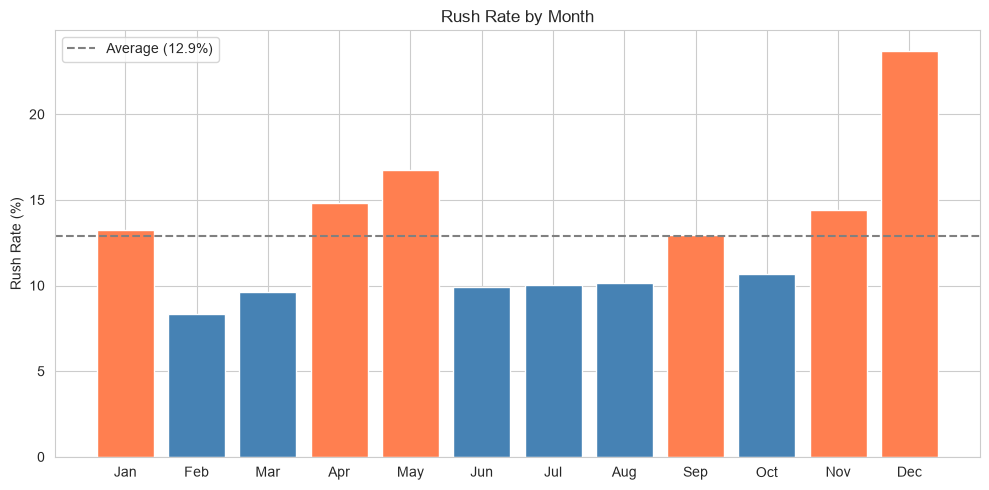

Average rush rate: 12.9%
Highest rate: Dec (23.7%)
Lowest rate: Feb (8.3%)
Highest absolute rush volume: May (319 rush orders/month avg)


In [11]:
tickets_df['is_rush'] = tickets_df['rush_fee'] > 0
rush_rate_by_month = tickets_df.groupby('month_num')['is_rush'].mean() * 100

avg_rush_rate = rush_rate_by_month.mean()
colors = ['coral' if val > avg_rush_rate else 'steelblue' for val in rush_rate_by_month.values]

plt.figure(figsize=(10, 5))
plt.bar(month_labels, rush_rate_by_month.values, color=colors)
plt.axhline(y=avg_rush_rate, color='gray', linestyle='--', label=f'Average ({avg_rush_rate:.1f}%)')
plt.ylabel('Rush Rate (%)')
plt.title('Rush Rate by Month')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Average rush rate: {avg_rush_rate:.1f}%')
print(f'Highest rate: {month_labels[rush_rate_by_month.idxmax() - 1]} ({rush_rate_by_month.max():.1f}%)')
print(f'Lowest rate: {month_labels[rush_rate_by_month.idxmin() - 1]} ({rush_rate_by_month.min():.1f}%)')

# absolute rush volume can tell a different story than rate alone, since a lower-rate
# month with much higher overall order volume can still generate more rush orders
years = tickets_df['date_received'].dt.year.nunique()
rush_count_by_month = tickets_df.groupby('month_num')['is_rush'].sum() / years
print(f'Highest absolute rush volume: {month_labels[rush_count_by_month.idxmax() - 1]} ({rush_count_by_month.max():.0f} rush orders/month avg)')

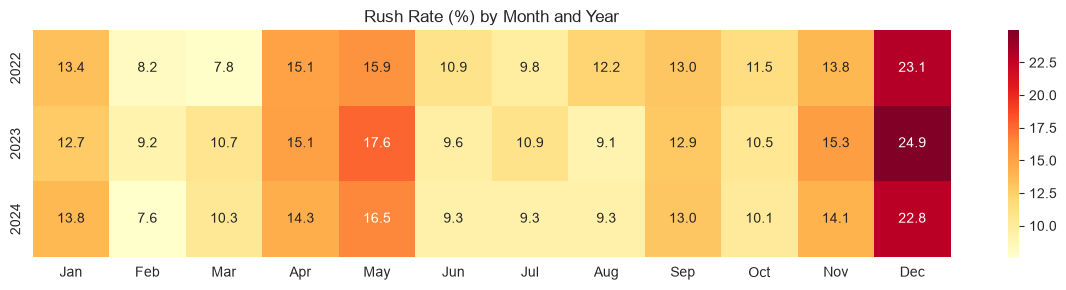

In [12]:
# heatmap of rush rate by month and year
rush_heatmap_data = tickets_df.groupby(['year', 'month_num'])['is_rush'].mean().unstack(level=1) * 100
rush_heatmap_data.columns = month_labels

plt.figure(figsize=(12, 3))
sns.heatmap(rush_heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Rush Rate (%) by Month and Year')
plt.ylabel('')
plt.tight_layout()
plt.show()